<a href="https://colab.research.google.com/github/Geethika1205/SML/blob/main/plantdisease.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
uploaded = files.upload()

Saving archive (12).zip to archive (12).zip


In [2]:
import zipfile

zip_path = "/content/archive (12).zip"
extract_path = "/content/PlantDoc"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [3]:
import os

dataset_path = "/content/PlantDoc"

for root, dirs, files in os.walk(dataset_path):
    print(root, len(files))

/content/PlantDoc 0
/content/PlantDoc/coffee___healthy 791
/content/PlantDoc/coffee___rust 602
/content/PlantDoc/coffee___red_spider_mite 167


In [4]:
from PIL import Image
import os

folder = "/content/PlantDoc"
sample = None

for root, dirs, files in os.walk(folder):
    for f in files[:1]:
        sample = os.path.join(root, f)

img = Image.open(sample)
img.show()

In [5]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

img_size = 224
batch_size = 32

train_gen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

train_data = train_gen.flow_from_directory(
    dataset_path,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    subset="training"
)

val_data = train_gen.flow_from_directory(
    dataset_path,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    subset="validation"
)

Found 1249 images belonging to 3 classes.
Found 311 images belonging to 3 classes.


In [6]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras import layers, models

# Base model
base_model = EfficientNetB0(
    include_top=False,
    weights='imagenet',
    input_shape=(224,224,3)
)

# Freeze early layers
for layer in base_model.layers:
    layer.trainable = False

# Attention block
def attention_block(x):
    attn = layers.Conv2D(1,1,activation='sigmoid')(x)
    return layers.multiply([x, attn])

x = base_model.output
x = attention_block(x)
x = layers.GlobalAveragePooling2D()(x)
output = layers.Dense(train_data.num_classes, activation='softmax')(x)

model = models.Model(base_model.input, output)

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [7]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [8]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=20
)

Epoch 1/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 92s 2s/step - accuracy: 0.4460 - loss: 0.9735 - val_accuracy: 0.5080 - val_loss: 0.9507
Epoch 2/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 31s 789ms/step - accuracy: 0.5068 - loss: 0.9734 - val_accuracy: 0.5080 - val_loss: 0.9499
Epoch 3/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 32s 828ms/step - accuracy: 0.5068 - loss: 0.9588 - val_accuracy: 0.5080 - val_loss: 0.9506
Epoch 4/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 33s 817ms/step - accuracy: 0.5068 - loss: 0.9541 - val_accuracy: 0.5080 - val_loss: 0.9530
Epoch 5/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 32s 791ms/step - accuracy: 0.5068 - loss: 0.9565 - val_accuracy: 0.5080 - val_loss: 0.9518
Epoch 6/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 32s 808ms/step - accuracy: 0.5068 - loss: 0.9517 - val_accuracy: 0.5080 - val_loss: 0.9538
Epoch 7/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 31s 777ms/step - accuracy: 0.5068 - loss: 0.9550 - val_accuracy: 0.5080 - val_loss: 0.9499
Epoch 8/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 33s 819ms/step - accuracy: 0.4852 - loss: 0.9589 - val_accurac

In [9]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    "best_model.h5",
    monitor='val_accuracy',
    save_best_only=True
)

In [10]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=30,
    callbacks=[early_stop, checkpoint]
)

Epoch 1/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 654ms/step - accuracy: 0.4859 - loss: 0.9635

40/40 ━━━━━━━━━━━━━━━━━━━━ 34s 855ms/step - accuracy: 0.5068 - loss: 0.9560 - val_accuracy: 0.5080 - val_loss: 0.9510
Epoch 2/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 33s 830ms/step - accuracy: 0.5068 - loss: 0.9557 - val_accuracy: 0.5080 - val_loss: 0.9525
Epoch 3/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 32s 793ms/step - accuracy: 0.5068 - loss: 0.9534 - val_accuracy: 0.5080 - val_loss: 0.9518
Epoch 4/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 33s 851ms/step - accuracy: 0.5068 - loss: 0.9582 - val_accuracy: 0.5080 - val_loss: 0.9497
Epoch 5/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 32s 811ms/step - accuracy: 0.5068 - loss: 0.9543 - val_accuracy: 0.5080 - val_loss: 0.9498
Epoch 6/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 42s 841ms/step - accuracy: 0.5068 - loss: 0.9527 - val_accuracy: 0.5080 - val_loss: 0.9496
Epoch 7/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 32s 799ms/step - accuracy: 0.5060 - loss: 0.9541 - val_accuracy: 0.5080 - val_loss: 0.9515
Epoch 8/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 33s 813ms/step - accuracy: 0.5068 - loss: 0.9536 - val_accuracy: 0.508

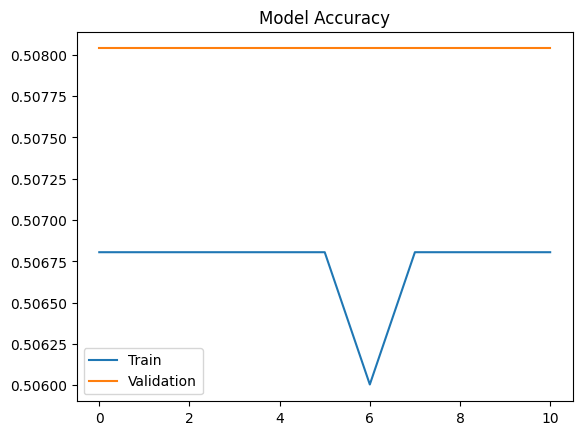

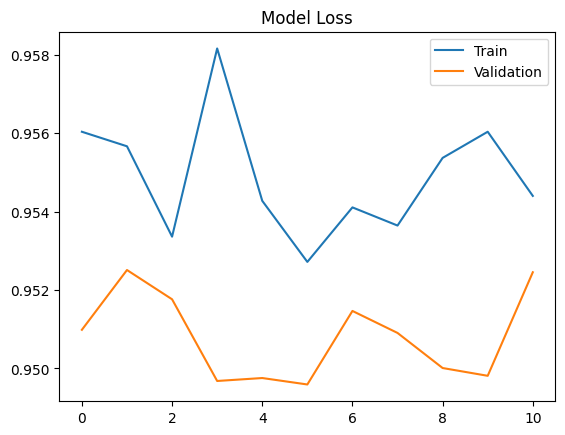

In [11]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.legend(['Train', 'Validation'])
plt.show()

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.legend(['Train', 'Validation'])
plt.show()

In [12]:
val_loss, val_acc = model.evaluate(val_data)
print("Validation Accuracy:", val_acc)

10/10 ━━━━━━━━━━━━━━━━━━━━ 6s 639ms/step - accuracy: 0.5080 - loss: 0.9497
Validation Accuracy: 0.5080385804176331


In [13]:
from tensorflow.keras import layers, models

def unet_model():
    inputs = layers.Input((224,224,3))

    # Encoder
    c1 = layers.Conv2D(32,3,activation='relu',padding='same')(inputs)
    p1 = layers.MaxPooling2D()(c1)

    c2 = layers.Conv2D(64,3,activation='relu',padding='same')(p1)

    # Decoder
    u1 = layers.UpSampling2D()(c2)
    concat = layers.Concatenate()([u1,c1])

    outputs = layers.Conv2D(1,1,activation='sigmoid')(concat)

    return models.Model(inputs, outputs)

seg_model = unet_model()

seg_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

seg_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 224, 224,  │        896 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 112, 112,  │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 112, 112,  │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d       │ (None, 224, 224,  │          0 │ conv2d_2[0][0]    │
│ (UpSampling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 224, 224,  │          0 │ up_sampling2d[0]… │
│ (Concatenate)       │ 96)               │            │ conv2d_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 224, 224,  │         97 │ concatenate[0][0] │
│                     │ 1)                │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 19,489 (76.13 KB)

 Trainable params: 19,489 (76.13 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:
import numpy as np

def disease_percentage(mask):
    disease_pixels = np.sum(mask > 0.5)
    total_pixels = mask.size
    return (disease_pixels / total_pixels) * 100

In [15]:
import cv2
import numpy as np
import os

def generate_mask(image_path):
    img = cv2.imread(image_path)
    img = cv2.resize(img, (224,224))

    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

    # detect brown/yellow diseased areas
    lower = np.array([10,40,40])
    upper = np.array([35,255,255])

    mask = cv2.inRange(hsv, lower, upper)
    return mask

In [16]:
from google.colab import files
uploaded = files.upload()

Saving dis.webp to dis.webp


(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

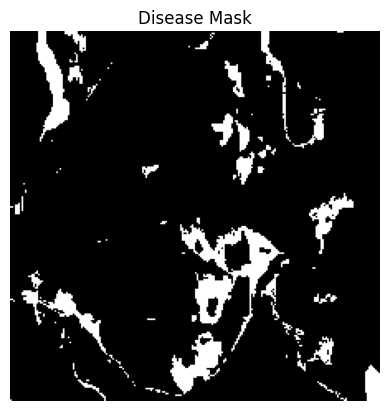

In [17]:
import matplotlib.pyplot as plt

sample_img = "/content/dis.webp"  # change path
mask = generate_mask(sample_img)

plt.imshow(mask, cmap='gray')
plt.title("Disease Mask")
plt.axis("off")

In [18]:
seg_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [19]:
def disease_percentage(mask):
    disease_pixels = np.sum(mask > 0)
    total_pixels = mask.size
    return (disease_pixels / total_pixels) * 100

In [20]:
import numpy as np
import cv2
import os

image_paths = []
masks = []

dataset_path = "/content/PlantDoc"

for root, dirs, files in os.walk(dataset_path):
    for file in files:
        if file.endswith(('.jpg','.png','.jpeg','.webp')):
            path = os.path.join(root,file)
            img = cv2.imread(path)
            img = cv2.resize(img,(224,224))

            hsv = cv2.cvtColor(img,cv2.COLOR_BGR2HSV)
            lower = np.array([10,40,40])
            upper = np.array([35,255,255])
            mask = cv2.inRange(hsv,lower,upper)

            image_paths.append(img/255.0)
            masks.append(mask/255.0)

X = np.array(image_paths)
Y = np.array(masks)
Y = Y.reshape(-1,224,224,1)

In [21]:
seg_model.fit(
    X, Y,
    batch_size=16,
    epochs=10,
    validation_split=0.2
)

Epoch 1/10
78/78 ━━━━━━━━━━━━━━━━━━━━ 9s 66ms/step - accuracy: 0.8320 - loss: 0.4368 - val_accuracy: 0.8017 - val_loss: 0.4118
Epoch 2/10
78/78 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - accuracy: 0.8469 - loss: 0.2990 - val_accuracy: 0.8457 - val_loss: 0.3034
Epoch 3/10
78/78 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - accuracy: 0.8832 - loss: 0.2539 - val_accuracy: 0.8814 - val_loss: 0.2643
Epoch 4/10
78/78 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - accuracy: 0.9003 - loss: 0.2254 - val_accuracy: 0.8974 - val_loss: 0.2391
Epoch 5/10
78/78 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - accuracy: 0.9097 - loss: 0.2098 - val_accuracy: 0.9041 - val_loss: 0.2275
Epoch 6/10
78/78 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - accuracy: 0.9159 - loss: 0.1997 - val_accuracy: 0.9007 - val_loss: 0.2274
Epoch 7/10
78/78 ━━━━━━━━━━━━━━━━━━━━ 5s 35ms/step - accuracy: 0.9195 - loss: 0.1930 - val_accuracy: 0.9112 - val_loss: 0.2144
Epoch 8/10
78/78 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - accuracy: 0.9208 - loss: 0.1899 - val_accuracy: 0.9115 - v